<a href="https://colab.research.google.com/github/Nada-Naveesh/Deep_Learning/blob/main/5a.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

In [17]:
#Step-1 Data Preparation - Pixel values
#Load the data and split into training and testing data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [18]:
#Reshape the image to 4-D format, including the channel dimension
x_dt = x_test.reshape ((x_test.shape[0]),28,28,1)

In [19]:
#Normalize the pixel values to the range [0,1]
x_train = x_train.astype('float32')/255
x_test = x_test.astype('float32')/255

In [20]:
#Perform one-hot encoding to convert labels to categorical (0/1)
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [21]:
#Step-2 Build the CNN model
model = models.Sequential()

In [22]:
# First convolutional layer
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(layers.MaxPooling2D((2, 2)))

In [23]:
# Second convolutional layer
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

In [24]:
# Third convolutional layer
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

In [25]:
# Flatten the output to feed it into a dense layer
model.add(layers.Flatten())

In [26]:
# Fully connected layer
model.add(layers.Dense(64, activation='relu'))

In [27]:
# Output layer with softmax activation for classification
model.add(layers.Dense(10, activation='softmax'))

In [28]:
# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 49s 63ms/step - accuracy: 0.8541 - loss: 0.4780 - val_accuracy: 0.9746 - val_loss: 0.0875
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 47s 62ms/step - accuracy: 0.9798 - loss: 0.0636 - val_accuracy: 0.9822 - val_loss: 0.0581
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 46s 61ms/step - accuracy: 0.9863 - loss: 0.0427 - val_accuracy: 0.9837 - val_loss: 0.0557
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 44s 58ms/step - accuracy: 0.9903 - loss: 0.0283 - val_accuracy: 0.9883 - val_loss: 0.0402
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 46s 62ms/step - accuracy: 0.9930 - loss: 0.0222 - val_accuracy: 0.9882 - val_loss: 0.0406
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9870 - loss: 0.0385
Test accuracy: 0.9902


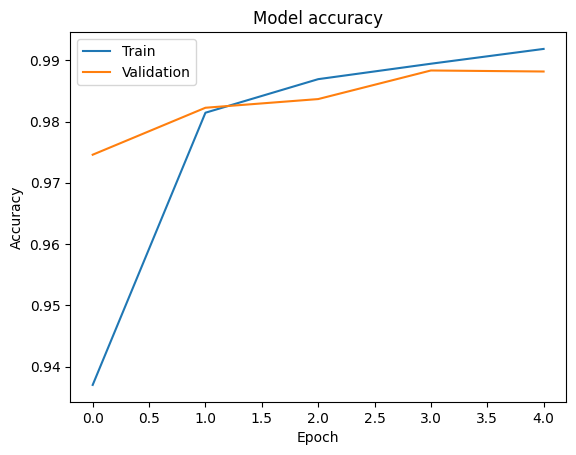

In [29]:
#Step-3 Training and Evaluation
#Train the model
history = model.fit(x_train, y_train, epochs=5, batch_size=64, validation_split=0.2)
# Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.savefig('Model Accuracy.tiff')
plt.show()

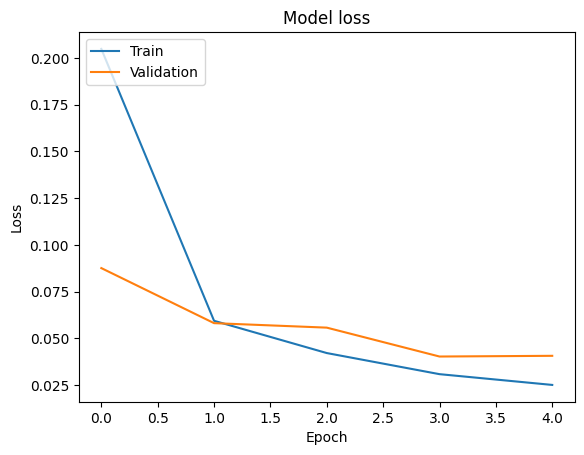

In [30]:
# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.savefig('Model loss.tiff')
plt.show()
